In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fiddlehead-competition/sample.csv
/kaggle/input/fiddlehead-competition/train.csv
/kaggle/input/fiddlehead-competition/test.csv


In [2]:
data = pd.read_csv('/kaggle/input/fiddlehead-competition/train.csv')
pd.set_option('display.max_columns', None)
data.head()

,category,head shape,head surface,head shade,marks,fragrance,blade_exist,blade_gap,blade_size,blade texture,stipe shape,base_stipe,stem surface above,stem surface below,stem color above,stem color below,shroud type,shroud color,annulus number,annulus type,powder color,tot_popul,environment,no_days,head_circumference,stem width,root width
0,1,5,2,4,1,5,1,0,1,4,0,1,2,1,7,7,0,2,1,4,1,3,0,29.0,4.516383,4.591127,5.110601
1,0,2,0,4,1,0,1,1,1,5,0,0,0,2,7,7,0,2,1,2,1,4,0,22.0,5.922174,4.979566,5.341753
2,0,5,2,9,0,5,1,0,0,7,1,0,2,2,7,6,0,2,1,2,7,5,2,23.0,7.089155,3.623844,7.488063
3,1,5,3,0,0,5,1,0,1,10,1,1,2,2,7,5,0,2,2,4,7,4,0,47.0,11.718708,7.452025,4.325183
4,1,5,0,3,0,6,1,1,0,0,1,3,2,2,7,7,0,2,1,2,2,5,2,9.0,8.795063,8.792288,4.309965


## Exploratory Data Analysis (EDA)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


##### Class Imbalance

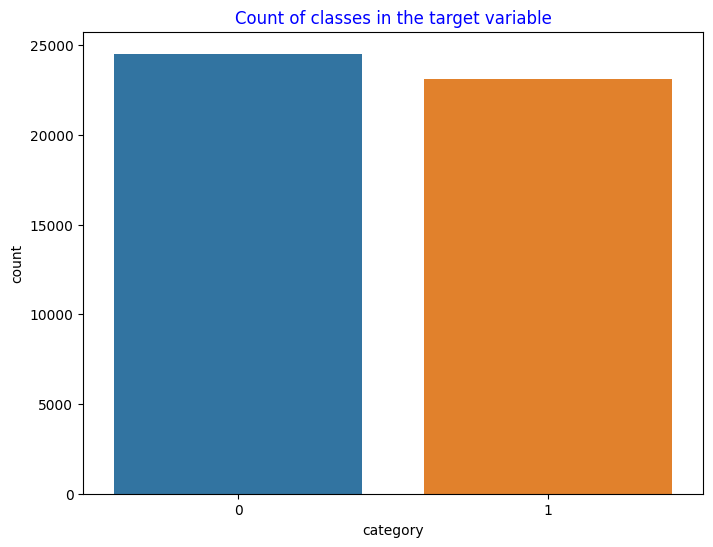

In [4]:
plt.rcParams['figure.figsize'] = (8,6)
sns.countplot(data=data, x='category')
plt.title("Count of classes in the target variable", c='Blue')
plt.show()

##### Missing Values

##### Data Description

In [6]:
data.describe()

,category,head shape,head surface,head shade,marks,fragrance,blade_exist,blade_gap,blade_size,blade texture,stipe shape,base_stipe,stem surface above,stem surface below,stem color above,stem color below,shroud type,shroud color,annulus number,annulus type,powder color,tot_popul,environment,no_days,head_circumference,stem width,root width
count,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.0,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000,47672.000000
mean,0.485463,3.330446,1.821803,4.502161,0.416660,4.119064,0.974891,0.156276,0.306679,4.826544,0.568132,1.113547,1.575852,1.593682,5.819223,5.805253,0.0,1.962934,1.066958,2.301477,3.616148,3.670687,1.528507,25.516655,10.557362,6.489564,5.492288
std,0.499794,1.611078,1.233591,2.560701,0.493011,2.132744,0.156458,0.363121,0.461120,3.527703,0.495341,1.054556,0.621504,0.681395,1.909019,1.909887,0.0,0.247473,0.264389,1.798526,2.385103,1.219842,1.728318,14.400900,4.336990,2.017228,1.441390
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000189,3.000010,3.000252
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,1.000000,6.000000,6.000000,0.0,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000,13.000000,6.808204,4.746114,4.251434
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,1.000000,1.000000,2.000000,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000,26.000000,10.591685,6.503170,5.483569
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,1.000000,1.000000,2.000000,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000,38.000000,14.323818,8.223328,6.745124
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,1.000000,4.000000,3.000000,3.000000,8.000000,8.000000,0.0,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000,50.000000,17.999531,9.999952,7.999905


#### Some visualizations to understand the data better

## Data Preprocessing

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47672 entries, 0 to 47671
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category            47672 non-null  int64  
 1   head shape          47672 non-null  int64  
 2   head surface        47672 non-null  int64  
 3   head shade          47672 non-null  int64  
 4   marks               47672 non-null  int64  
 5   fragrance           47672 non-null  int64  
 6   blade_exist         47672 non-null  int64  
 7   blade_gap           47672 non-null  int64  
 8   blade_size          47672 non-null  int64  
 9   blade texture       47672 non-null  int64  
 10  stipe shape         47672 non-null  int64  
 11  base_stipe          47672 non-null  int64  
 12  stem surface above  47672 non-null  int64  
 13  stem surface below  47672 non-null  int64  
 14  stem color above    47672 non-null  int64  
 15  stem color below    47672 non-null  int64  
 16  shro

In [23]:
data.isnull().sum()
data.columns

Index(['category', 'head shape', 'head surface', 'head shade', 'marks',
       'fragrance', 'blade_exist', 'blade_gap', 'blade_size', 'blade texture',
       'stipe shape', 'base_stipe', 'stem surface above', 'stem surface below',
       'stem color above', 'stem color below', 'shroud type', 'shroud color',
       'annulus number', 'annulus type', 'powder color', 'tot_popul',
       'environment', 'no_days', 'head_circumference', 'stem width',
       'root width'],
      dtype='object')

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, KBinsDiscretizer, LabelEncoder, MinMaxScaler

# Create transformers
imputer = SimpleImputer(strategy='most_frequent')
variance_threshold = VarianceThreshold()
mm= MinMaxScaler()
one_hot_encoder = OneHotEncoder()
standard_scaler = StandardScaler()
le= LabelEncoder()
k_bins_discretizer0 = KBinsDiscretizer(n_bins=3, strategy='quantile', encode='onehot')
k_bins_discretizer = KBinsDiscretizer(n_bins=3, strategy='quantile', encode='onehot')

# Define the preprocessing steps
preprocessor = ColumnTransformer([
    ('scaler', standard_scaler, [0,1, 2, 3, 4, 8, 11, 12, 13, 14, 16]),  # Apply scaling to numeric features
    ('discretizer0', k_bins_discretizer0, [22]),  # Apply ordinal encoding to ordinal feature
    ('discretizer', k_bins_discretizer, [23, 24, 25])  # Apply discretization to continuous features
], remainder='passthrough')

# Create the preprocessing pipeline
pl = Pipeline([
    ('preprocessor', preprocessor),
    ('variance_threshold', variance_threshold)])



In [26]:
data2 = data.copy()
training = data2.drop('category', axis=1)
X_train = pd.DataFrame(pl.fit_transform(training))
y_train = data2['category']

In [28]:
X_train.shape

(47672, 33)

In [29]:
import numpy as np
import pandas as pd
import sklearn
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler, SMOTENC, KMeansSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NeighbourhoodCleaningRule, InstanceHardnessThreshold, AllKNN

In [30]:
ksm = KMeansSMOTE(k_neighbors=6, cluster_balance_threshold=0.1)
X_res, y_res = ksm.fit_resample(X_train, y_train)

#adasyn = ADASYN(random_state=42)
# sampler = ADASYN(random_state=42, n_neighbors=2)
# X_res, y_res = sampler.fit_resample(X_train, y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [31]:
X_res.shape

(49063, 33)

## Fitting to the Model

In [32]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
# clf = ExtraTreesClassifier(max_samples = 0.6, n_estimators=120, oob_score=True, bootstrap=True, ccp_alpha=0.04)
# clf = ComplementNB()
# clf = AdaBoostClassifier(n_estimators=200, random_state=42)
# clf = GradientBoostingClassifier()
clf = XGBClassifier(n_estimators=200, random_state=42, max_depth=2)
# clf = GradientBoostingClassifier(n_estimators=160)
param_grid = {'n_estimators':[100,150,200,250,300,350,400,450,500,550,600]}
gs = GridSearchCV(estimator=clf, param_grid=param_grid, cv=10, scoring=make_scorer(f1_score))
gs.fit(X_res, y_res)
clf.fit(X_res, y_res)
# from xgboost import XGBClassifier
# clf = XGBClassifier()
# clf.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

In [35]:
clf.score(X_res, y_res)

0.6134969325153374

In [36]:
f1_score(y_res, clf.predict(X_res))

0.5958009165512096

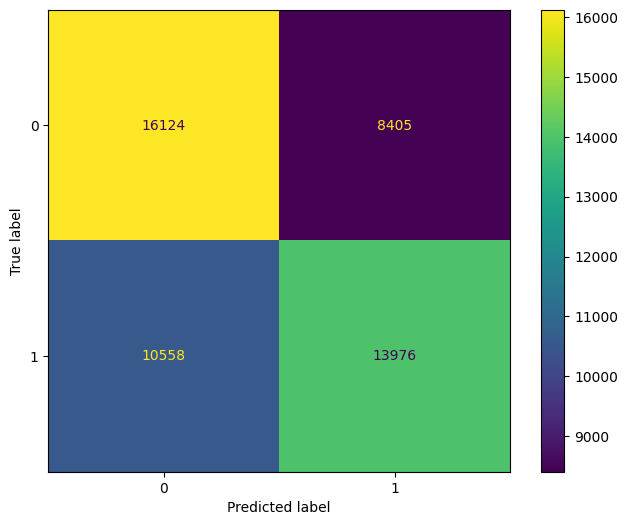

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score

ConfusionMatrixDisplay.from_estimator(clf, X_res, y_res)

In [38]:
test_data = pd.read_csv('/kaggle/input/fiddlehead-competition/test.csv')

X_test = pl.transform(test_data)
final = pd.DataFrame()
final['category'] = clf.predict(X_test)
final['id'] = list(range(X_test.shape[0]))


final.head()

,category,id
0,1,0
1,1,1
2,1,2
3,0,3
4,1,4


In [39]:
final.to_csv('submission.csv', index=False)

#### 